<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB
None
              age    trestbps        chol      thalch     oldpeak         num
count  908.000000  908.000000  908.000000  908.000000  846.000000  908.000000
mean    53.791850  133.430617  201.484581  135.957048    0.891253    1.008811

/tmp/ipykernel_4059/3670471753.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['oldpeak'].fillna(df['oldpeak'].median(), inplace=True)


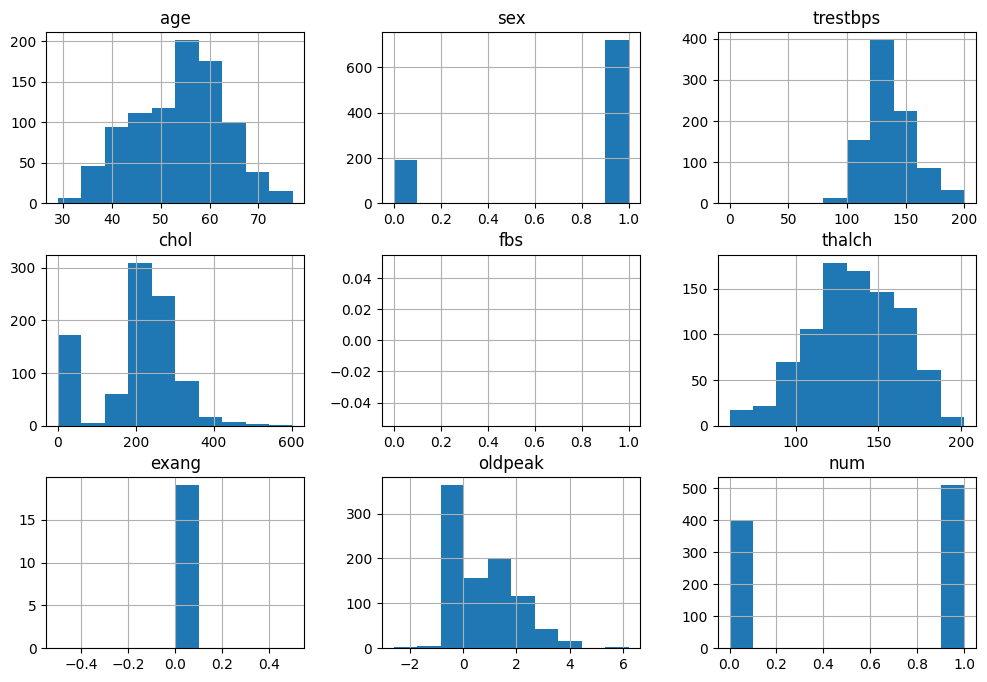

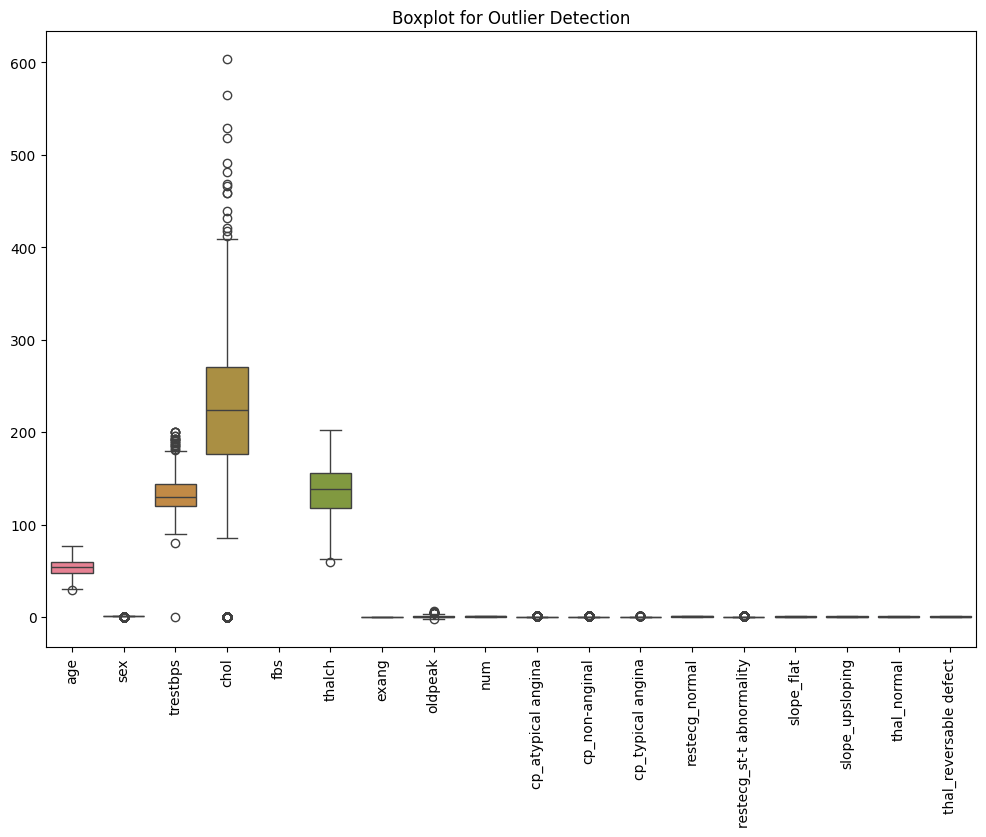

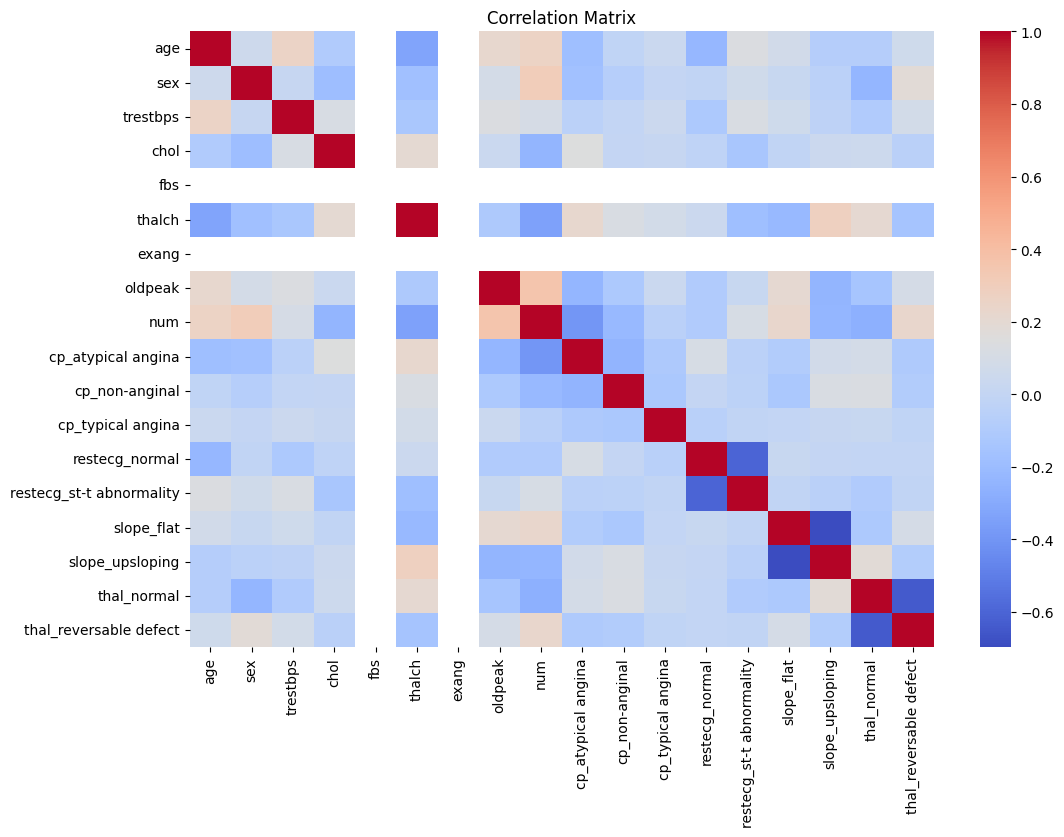


Accuracy: 0.7747252747252747

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.78      0.77        89
           1       0.78      0.77      0.78        93

    accuracy                           0.77       182
   macro avg       0.77      0.77      0.77       182
weighted avg       0.77      0.77      0.77       182



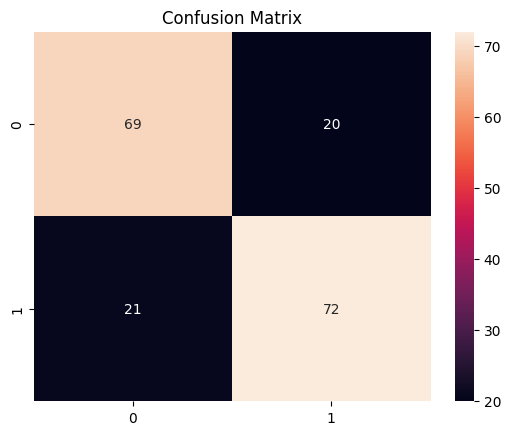

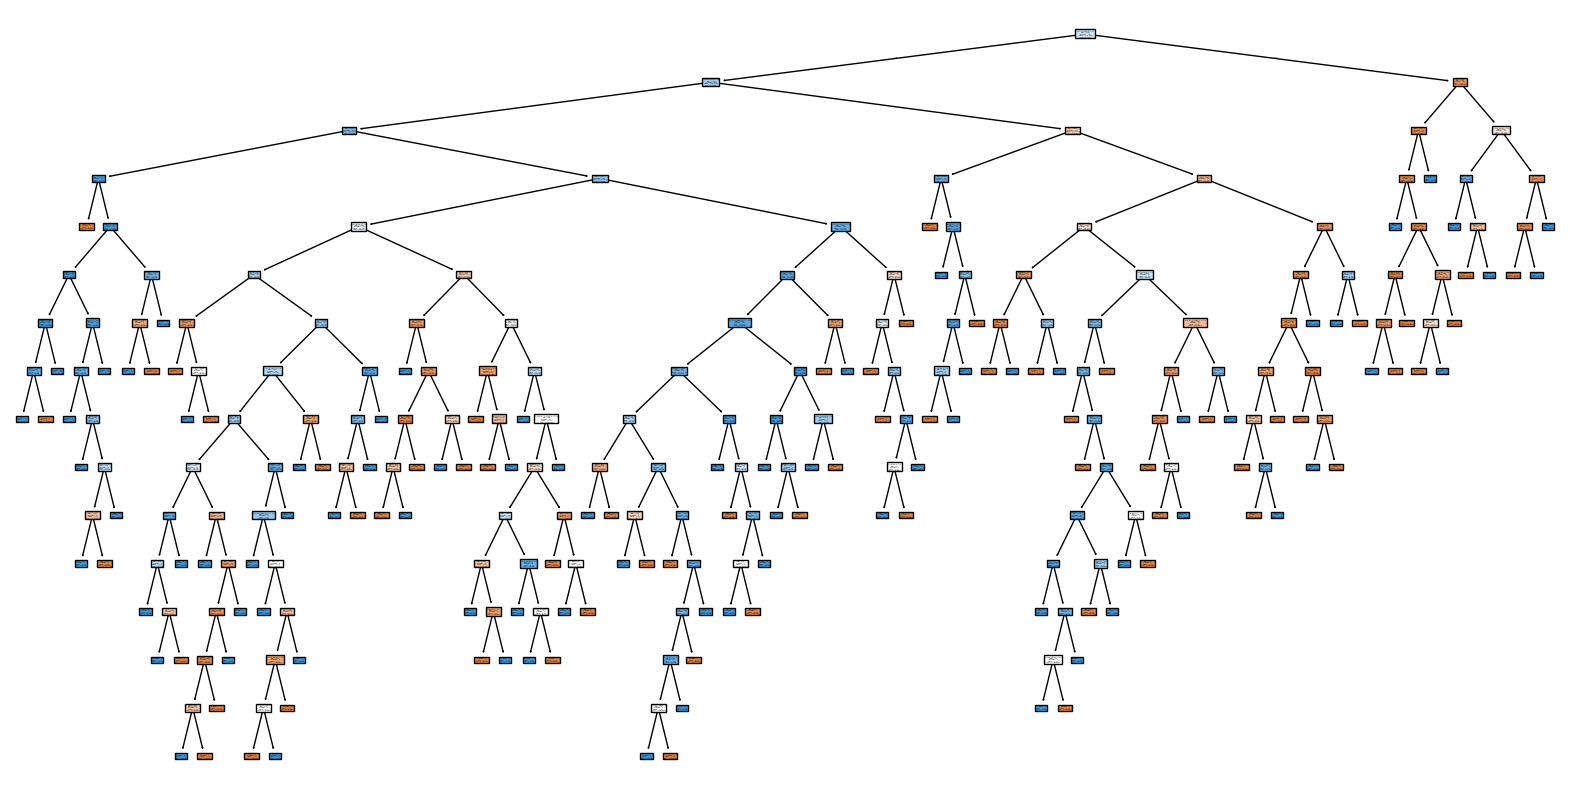


Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}

Project Completed Successfully ✅


In [1]:
# ============================================
# DECISION TREE - FINAL RESUBMISSION
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# LOAD DATA
# -------------------------
file_path = r"/content/heart_disease.xlsx"
df = pd.read_excel(file_path, sheet_name="Heart_disease")

print(df.info())
print(df.describe())
print(df.head())

# -------------------------
# MISSING VALUE HANDLING
# -------------------------
print("\nMissing Values Before:\n", df.isnull().sum())

# Handling missing values in 'oldpeak'
df['oldpeak'].fillna(df['oldpeak'].median(), inplace=True)

print("\nMissing Values After:\n", df.isnull().sum())

# -------------------------
# FEATURE ENGINEERING
# -------------------------

# Target variable conversion (binary classification)
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

# Convert categorical to numeric
df['fbs'] = df['fbs'].map({'TRUE':1, 'FALSE':0})
df['exang'] = df['exang'].map({'TRUE':1, 'FALSE':0})
df['sex'] = df['sex'].map({'Male':1, 'Female':0})

# One-hot encoding for multi-category variables
df = pd.get_dummies(df, columns=['cp','restecg','slope','thal'], drop_first=True)

# -------------------------
# EDA
# -------------------------

df.hist(figsize=(12,8))
plt.show()

plt.figure(figsize=(12,8))
sns.boxplot(df)
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# -------------------------
# TRAIN TEST SPLIT
# -------------------------
from sklearn.model_selection import train_test_split

X = df.drop('num', axis=1)
y = df['num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# MODEL BUILDING
# -------------------------
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# -------------------------
# MODEL EVALUATION
# -------------------------
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# -------------------------
# TREE VISUALIZATION
# -------------------------
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, class_names=['No Disease','Disease'], filled=True)
plt.show()

# -------------------------
# HYPERPARAMETER TUNING
# -------------------------
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth':[3,5,7,9],
    'min_samples_split':[2,5,10],
    'criterion':['gini','entropy']
}

grid = GridSearchCV(DecisionTreeClassifier(), params, cv=5)
grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)

# -------------------------
# FINAL NOTE
# -------------------------
print("\nProject Completed Successfully ✅")

In [2]:
'''
MISSING VALUE HANDLING:
The 'oldpeak' column contained missing values.
Median imputation was used because it is robust to outliers
and maintains the distribution of skewed numerical data.

FEATURE ENGINEERING:
1. Target variable 'num' was converted into binary (0 = No Disease, 1 = Disease)
   to make it suitable for classification.

2. Binary categorical variables such as 'sex', 'fbs', and 'exang'
   were converted into numeric form using mapping.

3. Multi-category variables like 'cp', 'restecg', 'slope', and 'thal'
   were transformed using One-Hot Encoding to avoid ordinal assumptions.

4. These transformations are necessary because machine learning models
   require numerical input and proper encoding improves model performance.
   '''

"\nMISSING VALUE HANDLING:\nThe 'oldpeak' column contained missing values. \nMedian imputation was used because it is robust to outliers \nand maintains the distribution of skewed numerical data.\n\nFEATURE ENGINEERING:\n1. Target variable 'num' was converted into binary (0 = No Disease, 1 = Disease)\n   to make it suitable for classification.\n\n2. Binary categorical variables such as 'sex', 'fbs', and 'exang' \n   were converted into numeric form using mapping.\n\n3. Multi-category variables like 'cp', 'restecg', 'slope', and 'thal' \n   were transformed using One-Hot Encoding to avoid ordinal assumptions.\n\n4. These transformations are necessary because machine learning models \n   require numerical input and proper encoding improves model performance.\n   "

In [3]:
'''
1. What are some common hyperparameters of Decision Tree models, and how do they affect the model's performance?

A Decision Tree model has several hyperparameters that control how the tree is built and help prevent overfitting.

Important Hyperparameters

1. max_depth
Controls the maximum depth of the tree.
Smaller depth → simpler model (reduces overfitting).
Larger depth → complex model (may overfit).

2. min_samples_split
Minimum number of samples required to split an internal node.
Higher values make the tree more general and reduce overfitting.

3. min_samples_leaf
Minimum number of samples required at a leaf node.
Helps smooth the model and prevents very small leaves.

4. max_features
Limits the number of features considered when splitting a node.
Helps reduce variance and improve generalization.

5. criterion
Function used to measure the quality of a split.
Common criteria:
Gini impurity
Entropy (Information Gain)
Effect on Model Performance
Proper tuning helps reduce overfitting and improve accuracy.
Small values → complex tree → possible overfitting.
Larger constraints → simpler tree → better generalization.

2. Difference Between Label Encoding and One-Hot Encoding?
Both methods are used to convert categorical data into numerical form so machine learning algorithms can process them.

Label Encoding
Label Encoding converts each category into a unique integer value.

Example:

Color	Label Encoding
Red	        0
Blue	    1
Green	    2

Advantages:
Simple and memory efficient.

Disadvantages:
Creates false ordinal relationships between categories.

Example:
The model may assume Green > Blue > Red, which may not be meaningful.

One-Hot Encoding
One-hot encoding creates separate binary columns for each category.

Example:

Color	Red  	Blue	Green
Red	      1	     0	      0
Blue	  0	     1	      0
Green	  0	     0	      1

Advantages:
Removes ordinal relationship problem.
Better for nominal categorical variables.

Disadvantages:
Increases number of features (dimensionality).

Key Differences
Feature	        Label Encoding	      One-Hot Encoding
Output	         Single column	     Multiple columns
Relationship	  Creates order     	No order
Memory Usage	     Low	             High
Best For	      Ordinal data	      Nominal data
'''

"\n1. What are some common hyperparameters of Decision Tree models, and how do they affect the model's performance?\n\nA Decision Tree model has several hyperparameters that control how the tree is built and help prevent overfitting.\n\nImportant Hyperparameters\n\n1. max_depth\nControls the maximum depth of the tree.\nSmaller depth → simpler model (reduces overfitting).\nLarger depth → complex model (may overfit).\n\n2. min_samples_split\nMinimum number of samples required to split an internal node.\nHigher values make the tree more general and reduce overfitting.\n\n3. min_samples_leaf\nMinimum number of samples required at a leaf node.\nHelps smooth the model and prevents very small leaves.\n\n4. max_features\nLimits the number of features considered when splitting a node.\nHelps reduce variance and improve generalization.\n\n5. criterion\nFunction used to measure the quality of a split.\nCommon criteria:\nGini impurity\nEntropy (Information Gain)\nEffect on Model Performance\nPrope